In [1]:
!pip install nltk 

In [4]:
!pip install torch 

In [6]:
!pip install torchvision 

In [8]:
!pip install transformers 

In [10]:
!pip install scikit-learn 

In [12]:
!pip install pandas 

In [14]:
!pip install fuzzywuzzy

In [28]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Initializing the lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function for Ingredient Parsing and Cleaning
def preprocess_ingredients(ingredients):
    # Tokenization, lemmatization, and stopword removal
    processed_ing = []
    for ingredient in ingredients.split(','):
        tokens = word_tokenize(ingredient.lower())
        tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
        processed_ing.append(' '.join(tokens))
    return processed_ing

# Load the recipe dataset
recipe_data = pd.read_csv('archive (1)/Cleaned_Indian_Food_Dataset.csv')  # Replace with your dataset path

# Function for Ingredient Vectorization
def vectorize_ingredients(ingredients):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(ingredients)
    return tfidf_matrix, vectorizer

# Load and preprocess ingredients from the new columns
recipe_data['processed_ingredients'] = recipe_data['TranslatedIngredients'].apply(lambda x: ' '.join(preprocess_ingredients(x)))

# Flatten the list of ingredients for vectorization
flat_ingredients = recipe_data['processed_ingredients'].tolist()
tfidf_matrix, vectorizer = vectorize_ingredients(flat_ingredients)

# Function for Semantic Matching
def match_ingredients(user_input, tfidf_matrix, vectorizer):
    user_processed = preprocess_ingredients(user_input)
    user_vector = vectorizer.transform([' '.join(user_processed)])
    cosine_sim = cosine_similarity(user_vector, tfidf_matrix)
    
    return cosine_sim[0]

# Example user input
user_input = "tomato, onion, garlic, spinach, rice"
similarity_scores = match_ingredients(user_input, tfidf_matrix, vectorizer)

# Find matched recipes
recipe_data['similarity'] = similarity_scores
matched_recipes = recipe_data[recipe_data['similarity'] > 0.1]  # Adjust threshold as needed

# Function for Fuzzy Logic based Health Evaluation (example)
def evaluate_healthiness(recipe):
    # Example health evaluation logic based on a hypothetical calorie threshold
    # Adjust according to your dataset
    if recipe['TotalTimeInMins'] < 30:  # Assuming quick recipes are healthier
        return "Healthy"
    elif recipe['TotalTimeInMins'] < 60:
        return "Normal"
    else:
        return "Unhealthy"

# Create health classification for matched recipes using .loc
matched_recipes.loc[:, 'health_label'] = matched_recipes.apply(evaluate_healthiness, axis=1)

# Final Output
final_output = matched_recipes[['TranslatedRecipeName', 'TranslatedIngredients', 'health_label', 'TotalTimeInMins', 'Cuisine', 'TranslatedInstructions', 'URL', 'Cleaned-Ingredients', 'image-url', 'Ingredient-count']]
print(final_output)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                   TranslatedRecipeName  \
1                            Spicy Tomato Rice (Recipe)   
2     Ragi Semiya Upma Recipe - Ragi Millet Vermicel...   
3     Gongura Chicken Curry Recipe - Andhra Style Go...   
7               Mexican Style Black Bean Burrito Recipe   
8                      Spicy Crunchy Masala Idli Recipe   
...                                                 ...   
5899    Spring Onion & Roasted Garlic Brown Rice Recipe   
5901                     Methi And Palak Paratha Recipe   
5903                  Jolada Roti Recipe - Jowar Bhakri   
5911                   Thai Yellow Curry Risotto Recipe   
5932  Creamy Spinach And Potato Breakfast Casserole ...   

                                  TranslatedIngredients health_label  \
1      2 teaspoon cashew - or peanuts, 1/2 Teaspoon ...      Healthy   
2     1 Onion - sliced,1 teaspoon White Urad Dal (Sp...       Normal   
3     1/2 teaspoon Turmeric powder (Haldi),1 tablesp...       Normal   
7  

C:\Users\saksh\AppData\Local\Temp\ipykernel_33904\2994546340.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matched_recipes.loc[:, 'health_label'] = matched_recipes.apply(evaluate_healthiness, axis=1)


In [32]:
print(recipe_data.shape)                 # Check the number of rows and columns

(5938, 11)


In [34]:
print(recipe_data.dtypes)                # Check data types

TranslatedRecipeName       object
TranslatedIngredients      object
TotalTimeInMins             int64
Cuisine                    object
TranslatedInstructions     object
URL                        object
Cleaned-Ingredients        object
image-url                  object
Ingredient-count            int64
processed_ingredients      object
similarity                float64
dtype: object


In [36]:
print(recipe_data.head())                 # Print the first few rows

                                TranslatedRecipeName  \
0                               Masala Karela Recipe   
1                         Spicy Tomato Rice (Recipe)   
2  Ragi Semiya Upma Recipe - Ragi Millet Vermicel...   
3  Gongura Chicken Curry Recipe - Andhra Style Go...   
4  Andhra Style Alam Pachadi Recipe - Adrak Chutn...   

                               TranslatedIngredients  TotalTimeInMins  \
0  1 tablespoon Red Chilli powder,3 tablespoon Gr...               45   
1   2 teaspoon cashew - or peanuts, 1/2 Teaspoon ...               15   
2  1 Onion - sliced,1 teaspoon White Urad Dal (Sp...               50   
3  1/2 teaspoon Turmeric powder (Haldi),1 tablesp...               45   
4   oil - as per use, 1 tablespoon coriander seed...               30   

                Cuisine                             TranslatedInstructions  \
0                Indian  To begin making the Masala Karela Recipe,de-se...   
1  South Indian Recipes  To make tomato puliogere, first cut the tom

In [38]:
print(recipe_data.isnull().sum())       # Show missing values per column

TranslatedRecipeName      0
TranslatedIngredients     0
TotalTimeInMins           0
Cuisine                   0
TranslatedInstructions    0
URL                       0
Cleaned-Ingredients       0
image-url                 0
Ingredient-count          0
processed_ingredients     0
similarity                0
dtype: int64


In [40]:
print(preprocess_ingredients("tomato, onion, garlic"))  # Check processing of ingredients

['tomato', 'onion', 'garlic']


In [42]:
user_input = "tomato, onion, garlic, spinach, rice"
print("Similarity Scores:", similarity_scores)  # Check similarity scores
print(matched_recipes[['TranslatedRecipeName', 'similarity']])  # Check matched recipes

Similarity Scores: [0.02939146 0.10156073 0.10717359 ... 0.         0.0241246  0.        ]
                                   TranslatedRecipeName  similarity
1                            Spicy Tomato Rice (Recipe)    0.101561
2     Ragi Semiya Upma Recipe - Ragi Millet Vermicel...    0.107174
3     Gongura Chicken Curry Recipe - Andhra Style Go...    0.100565
7               Mexican Style Black Bean Burrito Recipe    0.391704
8                      Spicy Crunchy Masala Idli Recipe    0.120917
...                                                 ...         ...
5899    Spring Onion & Roasted Garlic Brown Rice Recipe    0.179084
5901                     Methi And Palak Paratha Recipe    0.179571
5903                  Jolada Roti Recipe - Jowar Bhakri    0.121871
5911                   Thai Yellow Curry Risotto Recipe    0.126254
5932  Creamy Spinach And Potato Breakfast Casserole ...    0.172745

[893 rows x 2 columns]


In [44]:
print(matched_recipes[['TranslatedRecipeName', 'health_label']])  # Health assessments

                                   TranslatedRecipeName health_label
1                            Spicy Tomato Rice (Recipe)      Healthy
2     Ragi Semiya Upma Recipe - Ragi Millet Vermicel...       Normal
3     Gongura Chicken Curry Recipe - Andhra Style Go...       Normal
7               Mexican Style Black Bean Burrito Recipe       Normal
8                      Spicy Crunchy Masala Idli Recipe       Normal
...                                                 ...          ...
5899    Spring Onion & Roasted Garlic Brown Rice Recipe    Unhealthy
5901                     Methi And Palak Paratha Recipe       Normal
5903                  Jolada Roti Recipe - Jowar Bhakri       Normal
5911                   Thai Yellow Curry Risotto Recipe       Normal
5932  Creamy Spinach And Potato Breakfast Casserole ...    Unhealthy

[893 rows x 2 columns]


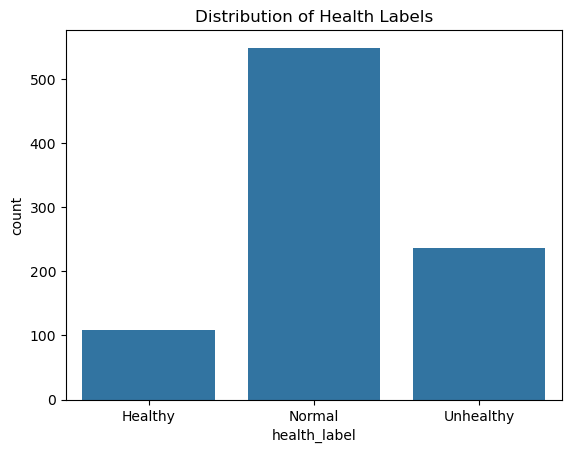

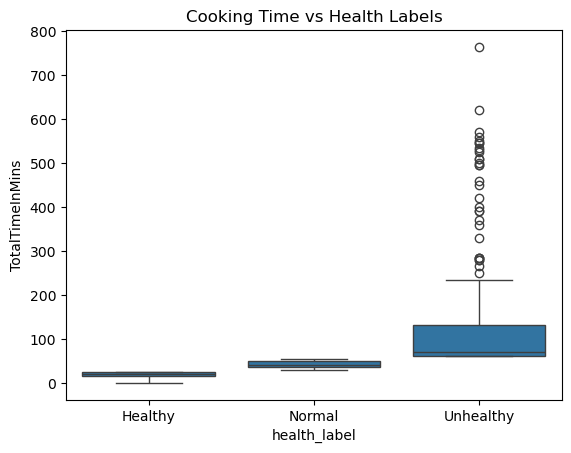

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Distribution of Health Labels
sns.countplot(data=matched_recipes, x='health_label')
plt.title("Distribution of Health Labels")
plt.show()

# Check for relationships between cooking time and healthiness
sns.boxplot(data=matched_recipes, x='health_label', y='TotalTimeInMins')
plt.title("Cooking Time vs Health Labels")
plt.show()

In [58]:
# Assuming the matched_recipes DataFrame has been created from previous steps
recommended_recipes = matched_recipes[['TranslatedRecipeName', 'TranslatedInstructions']].head(5)

# Display the recommended recipes in tabular format, without indexes
print(recommended_recipes.to_string(index=False))

                                       TranslatedRecipeName                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [64]:
recipe_data['similarity'] = similarity_scores
matched_recipes = recipe_data[recipe_data['similarity'] > 0.1]  # Adjust threshold as needed

# Evaluating healthiness
matched_recipes.loc[:, 'health_label'] = matched_recipes.apply(evaluate_healthiness, axis=1)

# Retrieve and display 5 recommended recipes with TranslatedRecipeName and TranslatedIngredients
recommended_recipes = matched_recipes[['TranslatedRecipeName', 'Cuisine']].head(5)

# Display the recommended recipes in tabular format
print(recommended_recipes.to_string(index=False))

                                       TranslatedRecipeName              Cuisine
                                 Spicy Tomato Rice (Recipe) South Indian Recipes
 Ragi Semiya Upma Recipe - Ragi Millet Vermicelli Breakfast South Indian Recipes
Gongura Chicken Curry Recipe - Andhra Style Gongura Chicken               Andhra
                    Mexican Style Black Bean Burrito Recipe              Mexican
                           Spicy Crunchy Masala Idli Recipe South Indian Recipes


C:\Users\saksh\AppData\Local\Temp\ipykernel_33904\2530408125.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matched_recipes.loc[:, 'health_label'] = matched_recipes.apply(evaluate_healthiness, axis=1)
